In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

accidents = pd.read_csv("../data/cleaned/accidents_cleaned.csv")
cities = pd.read_csv("../data/cleaned/city_violation_fatalities.csv")
states = pd.read_csv("../data/cleaned/state_accidents_long.csv")
violations = pd.read_csv("../data/cleaned/violation_severity_clean.csv")

In [2]:
violations_sorted = violations.sort_values(
    "fatality_rate_2023", ascending=False
)

violations_sorted[["category", "fatality_rate_2023", "accidents_2023", "killed_2023"]]


,category,fatality_rate_2023,accidents_2023,killed_2023
4,Use of mobile phone,40.49,7122,2884
1,Drunken driving/consumption of alcohol & drug,40.18,9143,3674
2,Driving on wrong side/Lane indiscipline,37.37,25242,9432
0,Over-speeding,35.80,328727,117682
5,Others,35.59,107909,38400
3,Jumping red light,33.52,2440,818


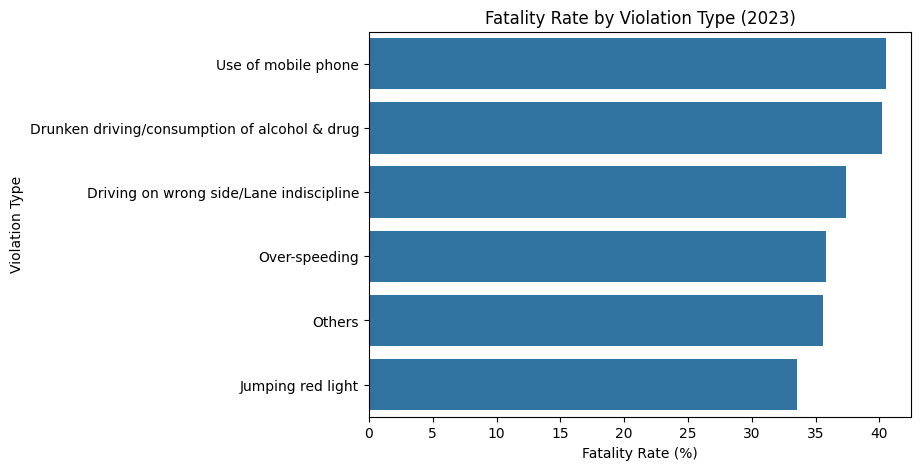

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(data=violations_sorted, x="fatality_rate_2023", y="category")
plt.title("Fatality Rate by Violation Type (2023)")
plt.xlabel("Fatality Rate (%)")
plt.ylabel("Violation Type")
plt.show()


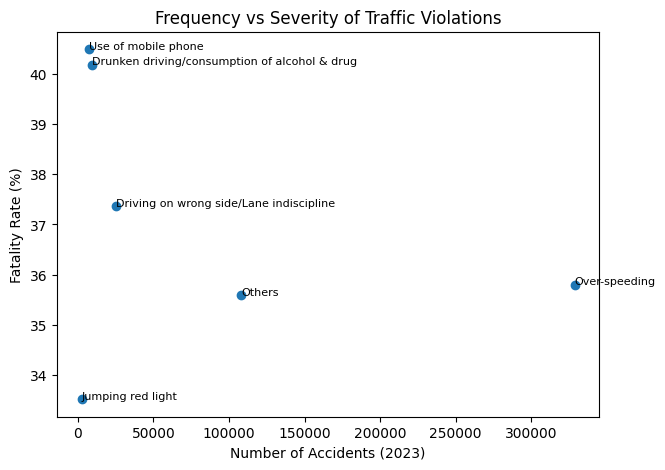

In [5]:
plt.figure(figsize=(7,5))
plt.scatter(
    violations["accidents_2023"],
    violations["fatality_rate_2023"]
)

for _, row in violations.iterrows():
    plt.text(
        row["accidents_2023"],
        row["fatality_rate_2023"],
        row["category"],
        fontsize=8
    )

plt.xlabel("Number of Accidents (2023)")
plt.ylabel("Fatality Rate (%)")
plt.title("Frequency vs Severity of Traffic Violations")
plt.show()


In [ ]:
top_cities = cities.sort_values("total_fatalities", ascending=False).head(10)

top_cities[["city", "total_fatalities"]]


,city,total_fatalities
11,Delhi,7285
6,Bengaluru,4575
19,Jaipur,4245
23,Kanpur,3190
2,Allahabad (Prayagraj),2910
29,Lucknow,2840
18,Jabalpur,2725
1,Ahmedabad,2675
39,Raipur,2535
10,Chennai,2515


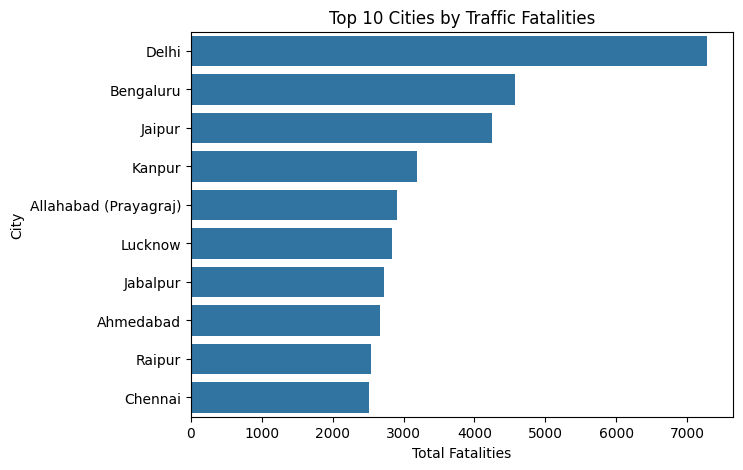

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(data=top_cities, x="total_fatalities", y="city")
plt.title("Top 10 Cities by Traffic Fatalities")
plt.xlabel("Total Fatalities")
plt.ylabel("City")
plt.show()


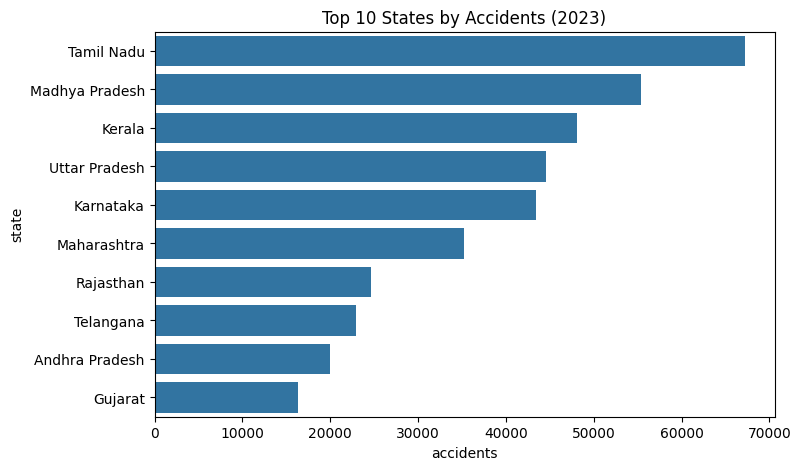

In [ ]:
latest_states = states[states["year"] == 2023]

top_states = latest_states.sort_values("accidents", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top_states, x="accidents", y="state")
plt.title("Top 10 States by Accidents (2023)")
plt.show()


In [11]:
from sqlalchemy import create_engine
import urllib
import pandas as pd

# mysql connection details 
username = "root"
password = urllib.parse.quote_plus("moksh@25")
host = "localhost"
port = "3306"
database = "urban_traffic_analytics"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

accidents.to_sql(
    name="accidents",
    con=engine,
    if_exists="replace",
    index=False
)

violations.to_sql(
    name="violations",
    con=engine,
    if_exists="replace",
    index=False
)

cities.to_sql(
    name="city_violation_fatalities",
    con=engine,
    if_exists="replace",
    index=False
)

states.to_sql(
    name="state_accidents",
    con=engine,
    if_exists="replace",
    index=False
)

175